## SegmenAI - Customer Segmentation App

##### This is the notebook for a Customer Segmentation project

Load all necessary libraries

In [98]:
import pandas as pd
import numpy as np
from datetime import datetime
import warnings
warnings.filterwarnings("ignore")

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

import matplotlib.pyplot as plt
import seaborn as sns

import cloudpickle

Load Customer Data

In [99]:
df = pd.read_csv("customerdata.csv", parse_dates=['InvoiceDate'], encoding='ISO-8859-1')

Inspect Dataset

In [100]:
df.head(5)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


Clean Null CustomerID entries

In [101]:
df = df[df['CustomerID'].notnull()]

Convert CustomerID to string

In [102]:
df['CustomerID'] = df['CustomerID'].apply(lambda x: str(int(x)))

In [103]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 406829 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    406829 non-null  object        
 1   StockCode    406829 non-null  object        
 2   Description  406829 non-null  object        
 3   Quantity     406829 non-null  int64         
 4   InvoiceDate  406829 non-null  datetime64[ns]
 5   UnitPrice    406829 non-null  float64       
 6   CustomerID   406829 non-null  object        
 7   Country      406829 non-null  object        
dtypes: datetime64[ns](1), float64(1), int64(1), object(5)
memory usage: 27.9+ MB


Create 'Total Amount' Column

In [104]:
df['TotalAmount'] = df['Quantity'] * df['UnitPrice']
df.head(5)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalAmount
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34


Save Latest Date in Dataset (For Calculating Recency Later)

In [105]:
snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

Caculate & Create Columns for Recency, Frequency & Monetary Value

In [106]:
rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,  # Recency
    'InvoiceNo': 'nunique',                                   # Frequency
    'TotalAmount': 'sum'                                      # Monetary
}).reset_index()

Rename columns for Recency, Frequency & Monetary Value

In [107]:
rfm.rename(columns={'InvoiceDate':'Recency','InvoiceNo':'Frequency','TotalAmount':'Monetary'}, inplace=True)
print(rfm.head(20))

   CustomerID  Recency  Frequency  Monetary
0       12346      326          2      0.00
1       12347        2          7   4310.00
2       12348       75          4   1797.24
3       12349       19          1   1757.55
4       12350      310          1    334.40
5       12352       36         11   1545.41
6       12353      204          1     89.00
7       12354      232          1   1079.40
8       12355      214          1    459.40
9       12356       23          3   2811.43
10      12357       33          1   6207.67
11      12358        2          2   1168.06
12      12359        8          6   6245.53
13      12360       52          3   2662.06
14      12361      287          1    189.90
15      12362        3         13   5154.58
16      12363      110          2    552.00
17      12364        8          4   1313.10
18      12365      291          3    320.69
19      12367        4          1    168.90


Standardize Features

In [108]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(rfm[['Recency', 'Frequency', 'Monetary']])

Perform Segmentation Using K-Means Clustering Algorithm

In [109]:
kmeans = KMeans(n_clusters=4, random_state=42)
rfm['Segment'] = kmeans.fit_predict(X_scaled)

Average RFM per Customer Segment

In [110]:
rfm.groupby("Segment")[["Recency","Frequency","Monetary"]].mean()

,Recency,Frequency,Monetary
Segment,,,
0,10.752577,28.510309,12168.264691
1,248.927577,1.805942,455.110716
2,5.090909,109.909091,124312.306364
3,42.780906,4.370550,1320.981506


Calculate Model's Sihouette Score

In [111]:
score = silhouette_score(X_scaled, rfm['Segment'])
print(f"Silhouette Score: {score:.2f}")

Silhouette Score: 0.61


In [112]:
segment_labels = {
    0: "High-Value Loyal",
    1: "Inactive Low-Value",
    2: "Recent Moderate",
    3: "Occasional Buyer"
}
rfm['Segment_Description'] = rfm['Segment'].map(segment_labels)

In [113]:
recommendations = {
    "High-Value Loyal": "Reward with VIP offers, loyalty perks, early access to products.",
    "Inactive Low-Value": "Send re-engagement campaigns with discounts or reminders.",
    "Recent Moderate": "Upsell or cross-sell complementary products.",
    "Occasional Buyer": "Encourage engagement through seasonal campaigns or bundles."
}


rfm['Recommendation'] = rfm['Segment_Description'].map(recommendations)

Plot Segment Distribution

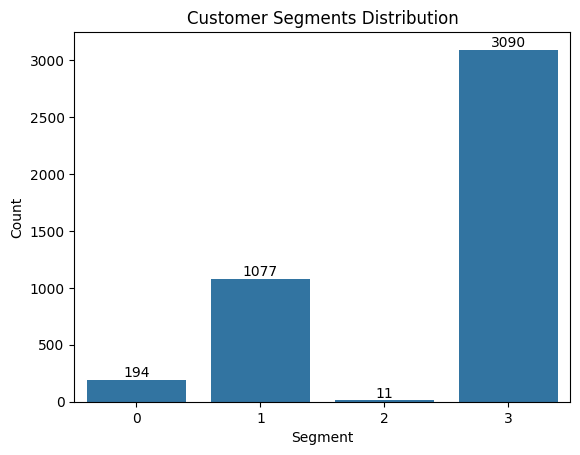

In [114]:
ax = sns.countplot(x='Segment', data=rfm)

for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'{int(height)}',
                (p.get_x() + p.get_width() / 2., height),
                ha='center', va='bottom')

ax.set_xticklabels(ax.get_xticklabels(), rotation=0)

plt.title("Customer Segments Distribution")
plt.xlabel("Segment")
plt.ylabel("Count")

plt.show()

Plot Monetary Contribution per Segment

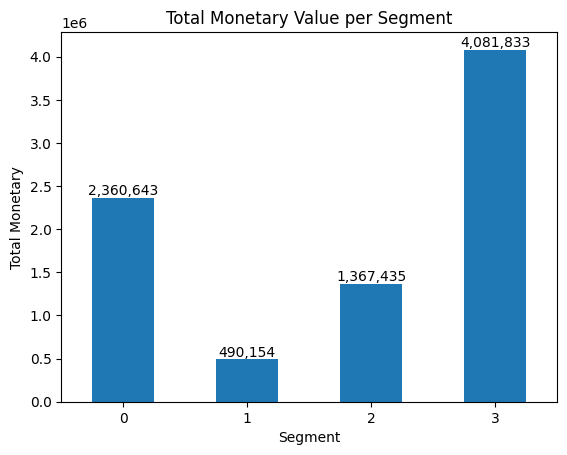

In [115]:
ax = rfm.groupby('Segment')['Monetary'].sum().plot(kind='bar')

for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'{height:,.0f}',   
                (p.get_x() + p.get_width() / 2., height),
                ha='center', va='bottom')
    
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)

plt.title("Total Monetary Value per Segment")
plt.xlabel("Segment")
plt.ylabel("Total Monetary")

plt.show()

Plot Average Recency per Segment

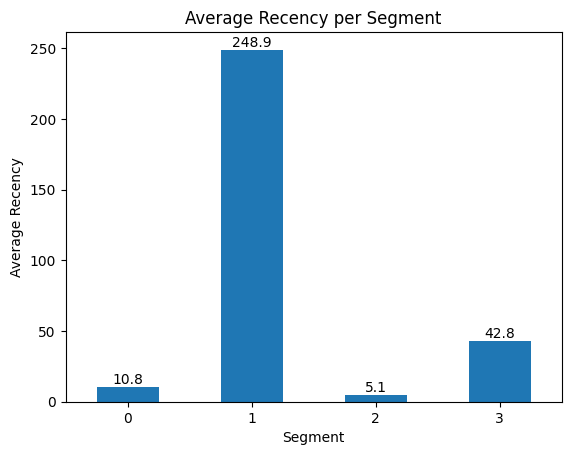

In [116]:
ax = rfm.groupby('Segment')['Recency'].mean().plot(kind='bar')

for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'{height:.1f}',   
                (p.get_x() + p.get_width() / 2., height),
                ha='center', va='bottom')
    
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)

plt.title("Average Recency per Segment")
plt.xlabel("Segment")
plt.ylabel("Average Recency")

plt.show()

Plot Average Frequency per Segment

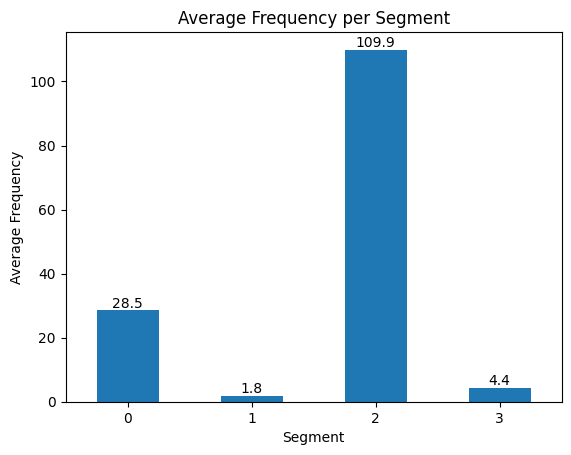

In [117]:
ax = rfm.groupby('Segment')['Frequency'].mean().plot(kind='bar')

for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'{height:.1f}',  
                (p.get_x() + p.get_width() / 2., height),
                ha='center', va='bottom')
    
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)

plt.title("Average Frequency per Segment")
plt.xlabel("Segment")
plt.ylabel("Average Frequency")

plt.show()

Save Scaler & Model

In [118]:
with open("models/kmeans_rfm.pkl", "wb") as f:
    cloudpickle.dump(kmeans, f)
    
with open("models/scaler_rfm.pkl", "wb") as f:
    cloudpickle.dump(scaler, f)

print("Model and scaler saved successfully!")

Model and scaler saved successfully!
